# Advanced Tutorial: Full Pipeline using the Lupus Dataset

This tutorial walks through the complete huCIRA analysis pipeline using the Lupus dataset as an example. It starts from raw, unprocessed data with ENSG symbols and covers data preparation, enrichment analysis, robustness filtering, and visualization. This comprehensive tutorial covers detailed explanations of all parameters, filtering mechanisms, and plotting options.

For minimal working examples, see the `quick_start_cytokine_enrichment.ipynb`, `quick_start_CIP_enrichment.ipynb`, and `quick_start_cell-cell_communication.ipynb` tutorials.

In [1]:
# Import core packages and the hucira package.

import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from tqdm import TqdmWarning

import hucira as hc

warnings.simplefilter("ignore", TqdmWarning)

start = time.time()

/lustre/groups/ml01/workspace/jenni.liu/conda_extern/envs/hucira/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
current_wd = os.getcwd()
print(f"Your current working directory: {current_wd}.")

Your current working directory: /ictstr01/home/icb/jenni.liu/all_projects/cytokine_dict_project/huCIRA/docs/notebooks.


## 1. Load input data

The two main input files for the huCIRA analysis are:
1. the Human Cytokine Dictionary 
2. your query transcriptome dataset. Here, we will download the Lupus dataset. It contains ENSG symbols for transcripts, which need to be converted to HGNC symbols. Additionally, the active layer in the dataset is currently scaled, so the raw counts have to be log-normalized for usage of huCIRA. For convenience, the Lupus data is subsampled to 10%.

The files are saved to or loaded from the current working directory. The path is explicitly specified here, although it's also the default saving location if left unspecified. Choose your own path (directory to project folder) as the workspace for this analysis. 

In [3]:
#### Load the human cytokine dictionary (full version) and the Lupus example adata.

df_hcd_all = hc.load_human_cytokine_dict(save_dir=current_wd, mini_version=False, force_download=False)
adata = hc.load_lupus_data(save_dir=current_wd, force_download=False)
sc.pp.subsample(adata, fraction=0.1, copy=False)
adata

Loading from: /ictstr01/home/icb/jenni.liu/all_projects/cytokine_dict_project/huCIRA/docs/notebooks/human_cytokine_dict.csv
Loading from: /ictstr01/home/icb/jenni.liu/all_projects/cytokine_dict_project/huCIRA/docs/notebooks/lupus.h5ad


AnnData object with n_obs × n_vars = 126367 × 30172
    obs: 'library_uuid', 'assay_ontology_term_id', 'mapped_reference_annotation', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'cell_state', 'sample_uuid', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_state', 'suspension_enriched_cell_types', 'suspension_uuid', 'suspension_type', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'sex_ontology_term_id', 'Processing_Cohort', 'ct_cov', 'ind_cov', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_pca', 'X_umap'

In [4]:
#### Optional for easy workflow:
# Enter celltype column name and condition column name of your query adata, which you can read from previous cell output

your_celltype_colname = "cell_type"
your_contrast_colname = "disease_state"

The Enrichment analysis needs two main pieces of information from the query adata: cell types and experimental (disease) conditions.

Annotations have to be examined manually, because naming convention between objects differ. Compare the cell type annotation of the dictionary with the naming convention of your query adata and re-annotate your query adata's annotation if necessary.


In [5]:
print(f"All cytokines in dictionary:\n  {df_hcd_all.cytokine.unique()}\n")
print(f"All celltypes in dictionary:\n  {df_hcd_all.celltype.unique()}\n")

print(f"All celltypes in query data:\n  {sorted(adata.obs[your_celltype_colname].unique())}\n")
print(
    f"All experimental states (contrasts/conditions) in query data:\n  {sorted(adata.obs[your_contrast_colname].unique())}\n"
)

All cytokines in dictionary:
  ['4-1BBL' 'ADSF' 'APRIL' 'BAFF' 'C5a' 'CD27L' 'CD30L' 'CD40L' 'CT-1'
 'Decorin' 'EGF' 'EPO' 'FGF-beta' 'FLT3L' 'FasL' 'G-CSF' 'GDNF' 'GITRL'
 'GM-CSF' 'HGF' 'IFN-alpha1' 'IFN-beta' 'IFN-epsilon' 'IFN-gamma'
 'IFN-lambda1' 'IFN-lambda2' 'IFN-lambda3' 'IFN-omega' 'IGF-1'
 'IL-1-alpha' 'IL-1-beta' 'IL-10' 'IL-11' 'IL-12' 'IL-13' 'IL-15' 'IL-16'
 'IL-17A' 'IL-17B' 'IL-17C' 'IL-17D' 'IL-17E' 'IL-17F' 'IL-19' 'IL-1Ra'
 'IL-2' 'IL-20' 'IL-21' 'IL-22' 'IL-23' 'IL-24' 'IL-26' 'IL-27' 'IL-3'
 'IL-31' 'IL-32-beta' 'IL-33' 'IL-34' 'IL-35' 'IL-36-alpha' 'IL-36Ra'
 'IL-4' 'IL-5' 'IL-6' 'IL-7' 'IL-8' 'IL-9' 'LIF' 'LIGHT' 'LT-alpha1-beta2'
 'LT-alpha2-beta1' 'Leptin' 'M-CSF' 'Noggin' 'OSM' 'OX40L' 'PRL' 'PSPN'
 'RANKL' 'SCF' 'TL1A' 'TNF-alpha' 'TPO' 'TRAIL' 'TSLP' 'TWEAK' 'VEGF']

All celltypes in dictionary:
  ['Intermediate_B_cell' 'NKT' 'CD8_Memory_T_cell' 'NK_CD56low' 'CD16_Mono'
 'NK_CD56hi' 'CD8_Naive_T_cell' 'pDC' 'ILC' 'MAIT' 'Naive_B_cell'
 'CD4_Naive_T_cell' 'T

To create celltype_combos, enter ordered lists that match the same cell types across different naming conventions in your data vs the human cytokine dictionary. "create_celltype_combos()" can help you to create the right format, but you can also format manually.

In [6]:
# Define celltype_combos, an input parameter for enrichment testing
adata_celltypes = [
    "B cell",
    "CD8-positive, alpha-beta T cell",
    "classical monocyte",
    "non-classical monocyte",
    "natural killer cell",
]

hcd_celltypes = ["B_cell", "CD8_T_cell", "CD14_Mono", "CD16_Mono", "NK_CD56hi"]

celltype_combos = hc.create_celltype_combos(adata_celltypes, hcd_celltypes)
print(celltype_combos)

# Define condition of interest
contrast = ("flare", "treated")
contrast_list = [("flare", "treated"), ("flare", "managed"), ("flare", "na")]
print(contrast)
print(contrast_list)

[('B cell', 'B_cell'), ('CD8-positive, alpha-beta T cell', 'CD8_T_cell'), ('classical monocyte', 'CD14_Mono'), ('non-classical monocyte', 'CD16_Mono'), ('natural killer cell', 'NK_CD56hi')]
('flare', 'treated')
[('flare', 'treated'), ('flare', 'managed'), ('flare', 'na')]


## 2. Process query data

The enrichment analysis requires **log-normalized expression data**, and gene identifiers must be provided as **HGNC gene symbols**, since the Human Cytokine Dictionary uses HGNC nomenclature.

To prepare your data in the appropriate format:

1. **Preprocess the expression data** and apply log normalization.
2. **Convert gene identifiers from Ensembl IDs (ENSG) to HGNC gene symbols.**  
   You may use any preferred method for this conversion; below we provide an example using the `mygene` module. Install it in your environment if it's missing.

In [7]:
# You can see that the active layer is currently storing scaled gene expression.
example_row = adata.X[:5].toarray()
example_row

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.25323954,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.35095528,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.36150452,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.37223315,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.2582687 ,  0.        ]], shape=(5, 30172), dtype=float32)

In [8]:
# Save layers
adata.layers["counts"] = adata.raw.X.copy()
adata.layers["scaled_original_counts"] = adata.X.copy()
adata.X = adata.layers["counts"]

# Basic quality checks:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Log-normalize:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

adata

AnnData object with n_obs × n_vars = 126343 × 20426
    obs: 'library_uuid', 'assay_ontology_term_id', 'mapped_reference_annotation', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'cell_state', 'sample_uuid', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_state', 'suspension_enriched_cell_types', 'suspension_uuid', 'suspension_type', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'sex_ontology_term_id', 'Processing_Cohort', 'ct_cov', 'ind_cov', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', 'log1p'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts',

In [9]:
import mygene

mg = mygene.MyGeneInfo()
results = mg.querymany(adata.var_names.tolist(), scopes="ensembl.gene", fields="symbol", species="human")
df = pd.DataFrame(results)

# Create mapping dict (fallback to Ensembl ID when symbol missing)
ensembl_to_symbol = df.set_index("query")["symbol"].fillna(df["query"]).to_dict()
adata.var["gene_symbol"] = adata.var_names.map(ensembl_to_symbol)
adata.var_names_make_unique()

keep_idx = ~adata.var["gene_symbol"].isna()
adata = adata[:, keep_idx].copy()
dup_idx = adata.var["gene_symbol"].duplicated(keep="first")
adata = adata[:, ~dup_idx].copy()
adata.var_names = adata.var["gene_symbol"]

querying 1-1000...done.
querying 1001-2000...done.
querying 2001-3000...done.
querying 3001-4000...done.
querying 4001-5000...done.
querying 5001-6000...done.
querying 6001-7000...done.
querying 7001-8000...done.
querying 8001-9000...done.
querying 9001-10000...done.
querying 10001-11000...done.
querying 11001-12000...done.
querying 12001-13000...done.
querying 13001-14000...done.
querying 14001-15000...done.
querying 15001-16000...done.
querying 16001-17000...done.
querying 17001-18000...done.
querying 18001-19000...done.
querying 19001-20000...done.
querying 20001-20426...done.
Finished.
7 input query terms found dup hits:
	[('ENSG00000261600', 2), ('ENSG00000234162', 2), ('ENSG00000227110', 2), ('ENSG00000233656', 2), ('E
4 input query terms found no hit:
	['ENSG00000250410', 'ENSG00000168078', 'ENSG00000189144', 'ENSG00000267058']
Pass "returnall=True" to return complete lists of duplicate or missing query terms.


In [10]:
# Check your transcript names. Now, they are in HGNC format and you can start the huCIRA analysis.
adata.var.head()

,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type,n_cells,gene_symbol
gene_symbol,,,,,,,,
RPL23AP21,True,ENSG00000228463,NCBITaxon:9606,gene,457,transcribed_processed_pseudogene,2063,RPL23AP21
LINC01409,True,LINC01409,NCBITaxon:9606,gene,1089,lncRNA,570,LINC01409
FAM87B,True,FAM87B,NCBITaxon:9606,gene,1960,lncRNA,20,FAM87B
LINC00115,True,LINC00115,NCBITaxon:9606,gene,874,lncRNA,844,LINC00115
FAM41C,True,FAM41C,NCBITaxon:9606,gene,919,lncRNA,1193,FAM41C


## 3. Run enrichment analysis

`run_all_enrichment_test()` is a wrapper around the core function `run_one_enrichment_test()`. It runs enrichment analyses across multiple cell types and over a range of filtering parameters, allowing you to assess how robust your results are. If you only need to analyze a single cell type with fixed parameters, you can use `run_one_enrichment_test()` directly. 

#### Gene set construction

Before running GSEA, gene sets (signatures) are built from the cytokine dictionary by filtering for differentially expressed genes. Three thresholds control which genes make it into a gene set. Higher values for these parameters produce smaller, more specific gene sets, potentially more precise but at the risk of dropping below `min_size`.

- **`threshold_lfc`** — minimum log-fold change a gene must show in response to a cytokine.
- **`threshold_expression`** — minimum expression level, filtering out lowly expressed genes.
- **`threshold_pval`** — maximum adjusted p-value, keeping only statistically significant genes.

With `run_all_enrichment_test()`, you can pass lists of values for `threshold_lfc` and `threshold_expression` to sweep over multiple filtering stringencies at once. This helps you gauge how sensitive your results are to the choice of these thresholds. This will later be important when computing robustness of results: Passing multiple values like `threshold_lfc=[0.5, 0.8, 1.0, 1.5]` generates multiple gene sets per cytokine. The robustness functions then assess whether enrichment is consistent across these variations. You can choose to run enrichment analyses either for **upregulated** or **downregulated** signals.

#### GSEA parameters

The enrichment analysis is based on pre-rank Gene Set Enrichment Analysis (GSEA). A few parameters control how it runs:

- **`min_size` / `max_size`** — gene sets smaller or larger than these bounds are excluded.
- **`permutation_num`** — number of permutations for estimating p-values. More permutations give more stable results but take longer.
- **`weight`** — controls how much the gene-level ranking metric influences the enrichment score. The default of 1.0 is standard weighted GSEA; setting it to 0.0 gives an unweighted statistic.
- **`seed`** — random seed for reproducibility.

#### Ranking statistic

By default, genes are ranked using the **signal-to-noise ratio (SNR)**, which measures how large the expression difference between two groups is relative to the variability within each group. If you prefer a different ranking metric, you can pass your own function via `ranking_statistic_fn`. More details on how to do define your custom metric can be found in the quick start tutorial `quick_start_cytokine_enrichment.ipynb`.


In [11]:
# Enrichment analysis for one contrast

enrichment_results = hc.run_all_enrichment_test(
    adata=adata,
    df=df_hcd_all,
    contrast_combo=contrast,
    celltype_combos=celltype_combos,
    contrast_column=your_contrast_colname,
    celltype_column=your_celltype_colname,
    # The following parameters are optional (they have default specifications)
    direction="upregulated",
    # Filtering parameters for gene set construction (of dictionary or gene program)
    threshold_lfc=1.0,
    threshold_expression=0.0,
    threshold_pval=0.01,
    # GSEA parameters
    min_size=10,
    max_size=1000,
    permutation_num=1000,
    weight=1.0,
    seed=2025,
    ranking_statistic_fn=None,
)

# Look at all enrichment results (reduced view to columns of interest, not all statistics)
enrichment_results[
    [
        "celltype_combo",
        "cytokine",
        "contrast",
        "direction",
        "ES",
        "NES",
        "NOM p-val",
        "FDR q-val",
        "FWER p-val",
        "frac_shared_genes_signature",
        "Lead_genes",
        "threshold_lfc",
        "threshold_expression",
    ]
].sort_values("NES", ascending=False).head()

Computing gene sets of Human Cytokine Dictionary for B_cell.
Running enrichment for contrast: flare_vs_treated
2026-03-10 15:07:30,408 [WARNING] Duplicated values found in preranked stats: 35.08% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
Computing gene sets of Human Cytokine Dictionary for CD8_T_cell.
Running enrichment for contrast: flare_vs_treated
2026-03-10 15:07:32,995 [WARNING] Duplicated values found in preranked stats: 26.07% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
Computing gene sets of Human Cytokine Dictionary for CD14_Mono.
Running enrichment for contrast: flare_vs_treated
2026-03-10 15:07:35,848 [WARNING] Duplicated values found in preranked stats: 27.77% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
Computing gene sets of Human Cytokine Dictionary for CD16_Mono.
Running enrichment for contrast: flare_vs_treated
2026-03-10 15:07:3

,celltype_combo,cytokine,contrast,direction,ES,NES,NOM p-val,FDR q-val,FWER p-val,frac_shared_genes_signature,Lead_genes,threshold_lfc,threshold_expression
0,classical monocyte (CD14_Mono),IL-6,flare_vs_treated,upregulated,0.503346,1.591792,0.005445,0.017648,0.045,0.892857,ENPP2;VCAN;MS4A4A;KCNJ15;OLFML2B;GPR34;LINC026...,1.0,0.0
2,classical monocyte (CD14_Mono),IL-10,flare_vs_treated,upregulated,0.370541,1.409779,0.003257,0.049564,0.206,0.852174,CD14;RGS2;TXLNB;PTGFRN;SCARB1;SCD;KCNMB4;SPIRE...,1.0,0.0
5,classical monocyte (CD14_Mono),IL-21,flare_vs_treated,upregulated,0.553939,1.278504,0.167984,0.082107,0.435,0.650000,FCGR1A;ENPP2;C1orf21;ABLIM3;ABHD17C;FAM20A,1.0,0.0
5,non-classical monocyte (CD16_Mono),IL-10,flare_vs_treated,upregulated,0.367412,1.238451,0.039683,0.585217,0.62,0.871186,RFLNB;CAMKK1;PVR;S100A9;FPR1;ATP13A3;ZNRF1;INP...,1.0,0.0
2,B cell (B_cell),IL-21,flare_vs_treated,upregulated,0.465881,1.223775,0.170391,1.0,0.645,0.914286,BATF;FURIN;SLC2A5;LMO2;LINC02156;BUB1;LINC0241...,1.0,0.0


You can combine results from multiple experimental conditions into a single DataFrame by looping over all contrasts of interest. The variable *contrast_list* was defined in Section 1. This can be useful if you want to aggregate or export results, or perform downstream analyses such as plotting multiple heatmaps side by side. For this tutorial, however, most steps focus on evaluating one contrast at a time.

In [12]:
# To run enrichment analysis for several contrasts, loop through all contrast conditions you are interested in.

all_results = []
for contrast in contrast_list:
    enrichment_df = hc.run_all_enrichment_test(
        adata=adata,
        df=df_hcd_all,
        contrast_combo=contrast,
        celltype_combos=celltype_combos,
        contrast_column=your_contrast_colname,
        celltype_column=your_celltype_colname,
        direction="upregulated",
        threshold_lfc=1.0,
        threshold_expression=0.0,
        threshold_pval=0.01,
        min_size=10,
        max_size=1000,
        permutation_num=1000,
        weight=1.0,
        seed=2025,
        ranking_statistic_fn=None,
    )
    all_results.append(enrichment_df)
multi_contrast_enrichment_results = pd.concat(all_results, ignore_index=True)

# Look at all enrichment results (reduced view to columns of interest, not all statistics)
multi_contrast_enrichment_results[
    [
        "celltype_combo",
        "cytokine",
        "contrast",
        "direction",
        "ES",
        "NES",
        "NOM p-val",
        "FDR q-val",
        "FWER p-val",
        "frac_shared_genes_signature",
        "Lead_genes",
        "threshold_lfc",
        "threshold_expression",
    ]
].sort_values("NES", ascending=False)

Computing gene sets of Human Cytokine Dictionary for B_cell.
Running enrichment for contrast: flare_vs_treated
2026-03-10 15:07:43,298 [WARNING] Duplicated values found in preranked stats: 35.08% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
Computing gene sets of Human Cytokine Dictionary for CD8_T_cell.
Running enrichment for contrast: flare_vs_treated
2026-03-10 15:07:45,733 [WARNING] Duplicated values found in preranked stats: 26.07% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
Computing gene sets of Human Cytokine Dictionary for CD14_Mono.
Running enrichment for contrast: flare_vs_treated
2026-03-10 15:07:48,516 [WARNING] Duplicated values found in preranked stats: 27.77% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
Computing gene sets of Human Cytokine Dictionary for CD16_Mono.
Running enrichment for contrast: flare_vs_treated
2026-03-10 15:07:5

,celltype_combo,cytokine,contrast,direction,ES,NES,NOM p-val,FDR q-val,FWER p-val,frac_shared_genes_signature,Lead_genes,threshold_lfc,threshold_expression
232,natural killer cell (NK_CD56hi),IFN-beta,flare_vs_na,upregulated,0.806282,2.530997,0.0,0.0,0.0,0.877419,IFI44L;ISG15;IFITM1;LY6E;IFI6;MX1;IFITM3;XAF1;...,1.0,0.0
164,B cell (B_cell),IFN-beta,flare_vs_na,upregulated,0.805907,2.49256,0.0,0.0,0.0,0.904110,IFI44L;IFITM1;ISG15;MX1;LY6E;EIF2AK2;IFI44;IFI...,1.0,0.0
233,natural killer cell (NK_CD56hi),IFN-omega,flare_vs_na,upregulated,0.80324,2.488184,0.0,0.0,0.0,0.875000,IFI44L;ISG15;LY6E;MX1;PRF1;IFITM3;XAF1;IFI44;G...,1.0,0.0
177,"CD8-positive, alpha-beta T cell (CD8_T_cell)",IFN-gamma,flare_vs_na,upregulated,0.880601,2.468958,0.0,0.0,0.0,0.904110,IFI44L;IFITM1;ISG15;IFI6;MX1;IFI44;EIF2AK2;OAS...,1.0,0.0
178,"CD8-positive, alpha-beta T cell (CD8_T_cell)",IL-2,flare_vs_na,upregulated,0.812445,2.450793,0.0,0.0,0.0,0.922156,IFI44L;IFITM1;ISG15;LY6E;IFI6;GZMH;PRF1;GZMB;M...,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
47,non-classical monocyte (CD16_Mono),C5a,flare_vs_treated,upregulated,-0.785597,-1.820491,0.002381,0.010364,0.005056,0.818182,CTSL;ADM;SLC16A10;HS3ST1;LGALS1;LILRA2,1.0,0.0
15,"CD8-positive, alpha-beta T cell (CD8_T_cell)",IFN-gamma,flare_vs_treated,upregulated,-0.54836,-1.908967,0.0,0.0,0.0,0.904110,ISG15;IFI6;IFITM1;ISG20;TYMP;MX1;IFI44L;EPSTI1...,1.0,0.0
191,classical monocyte (CD14_Mono),TL1A,flare_vs_na,upregulated,-0.83048,-1.965004,0.0,0.005078,0.002103,0.611111,MT-CO2;DUSP1;CSF1,1.0,0.0
14,"CD8-positive, alpha-beta T cell (CD8_T_cell)",IFN-alpha1,flare_vs_treated,upregulated,-0.716089,-2.157756,0.0,0.0,0.0,0.942857,ISG15;IFI6;TYMP;MX1;IFI44L;EPSTI1;IRF7;IFIT1;L...,1.0,0.0


#### CIP enrichment

Cytokine-induced gene program enrichment analysis is ran in a very similar way. Please refer to the `quick_start_CIP_enrichment.ipynb` tutorial for details.

## 4. Identify robust and significant results

Since `run_all_enrichment_test()` runs enrichment across multiple filtering thresholds, each cytokine–cell type pair can produce several results — one per parameter combination. This lets us assess whether a result holds up across different gene set constructions or only appears under one specific setting.

Robustness and significance are determined by two criteria:

1. **Is the result evaluable often enough?** Depending on the filtering thresholds, some gene sets may end up too small (or too large) for GSEA to run (see `min_size`/`max_size` in `run_all_enrichment_test`). The `threshold_valid` parameter sets the minimum fraction of parameter combinations that must yield a valid result. Cytokines that are only evaluable under very few settings are discarded.

2. **Is the result significant often enough?** Among the valid results, `threshold_below_alpha` sets the minimum fraction that must be significant (based on the FDR q-value). A cytokine that is only significant under one particular filtering setting is less reliable than one that is consistently significant across many.

Results passing both criteria are considered **robust**. They hold up across different gene set constructions rather than depending on a single parameter choice.

Two functions apply these criteria:

- `check_robustness` filters for a single q-value threshold and directly returns the filtered enrichment results.
- `get_robust_significant_results` additionally sweeps over three significance thresholds (`alphas`), which get assigned signficance stars. By default, alphas will represent [0.1, 0.05, 0.01]. Returns three DataFrames, the first two of which are used for plotting the enrichment heatmap. The main difference to `check_robustness` lies in its generation of functional and plot-ready outputs.

In [13]:
robust_results = hc.check_robustness(
    enrichment_results,
    threshold_qval=0.01,  # direct impact on NES results: filters FDR q-val
    threshold_valid=0.1,
    threshold_below_alpha=0.9,
)
robust_results

100%|██████████| 5/5 [00:00<00:00, 16.85it/s]


,celltype_combo,contrast,cytokine,frac_valid,frac_significant,is_robust,NES_min,NES_max,FDR q-val,qval_threshold,threshold_frac_below_alpha
0,"CD8-positive, alpha-beta T cell (CD8_T_cell)",flare_vs_treated,IL-1-beta,1.0,1.0,True,-2.215796,-2.215796,0.0,0.01,0.9
1,"CD8-positive, alpha-beta T cell (CD8_T_cell)",flare_vs_treated,IFN-alpha1,1.0,1.0,True,-2.157756,-2.157756,0.0,0.01,0.9
2,"CD8-positive, alpha-beta T cell (CD8_T_cell)",flare_vs_treated,IFN-gamma,1.0,1.0,True,-1.908967,-1.908967,0.0,0.01,0.9


In [14]:
nes_plot_df, annot_plot_df, robust_results = hc.get_robust_significant_results(
    results=enrichment_results,
    alphas=[0.1, 0.05, 0.01],
    threshold_valid=0.1,
    threshold_below_alpha=0.9,
    display_robust_results=True,
)

Star annotation mapping: * = 0.1, ** = 0.05, *** = 0.01
The contrast present in your enrichment results are: ['flare_vs_treated'], but computing robustness only for: 'flare_vs_treated'
100%|██████████| 5/5 [00:00<00:00, 26.71it/s]
Contrast: flare_vs_treated


,contrast,celltype_combo,cytokine,qval_threshold
0,flare_vs_treated,"CD8-positive, alpha-beta T cell (CD8_T_cell)",IFN-alpha1,0.01
1,flare_vs_treated,"CD8-positive, alpha-beta T cell (CD8_T_cell)",IFN-beta,0.05
2,flare_vs_treated,"CD8-positive, alpha-beta T cell (CD8_T_cell)",IFN-gamma,0.01
3,flare_vs_treated,"CD8-positive, alpha-beta T cell (CD8_T_cell)",IFN-omega,0.05
4,flare_vs_treated,"CD8-positive, alpha-beta T cell (CD8_T_cell)",IL-1-beta,0.01
5,flare_vs_treated,"CD8-positive, alpha-beta T cell (CD8_T_cell)",IL-15,0.05
6,flare_vs_treated,"CD8-positive, alpha-beta T cell (CD8_T_cell)",IL-2,0.05
7,flare_vs_treated,"CD8-positive, alpha-beta T cell (CD8_T_cell)",IL-27,0.05
8,flare_vs_treated,"CD8-positive, alpha-beta T cell (CD8_T_cell)",IL-7,0.05
9,flare_vs_treated,classical monocyte (CD14_Mono),IL-10,0.05


You can see that the output `robust_results` contains similar information for both functions. However, `get_robust_significant_results` returns a set of enrichment results that pass at least one of the three `qval_thresholds` (*alphas*). All output dataframes from `get_robust_significant_results` are then used as input for the plotting function. In particular, take a look at *nes_plot_df* and *annot_plot_df*, which will be visualized as a heatmap in the next section.

In [15]:
nes_plot_df

celltype_combo,B cell (B_cell),"CD8-positive, alpha-beta T cell (CD8_T_cell)",classical monocyte (CD14_Mono),natural killer cell (NK_CD56hi),non-classical monocyte (CD16_Mono)
cytokine,,,,,
C5a,NaN,NaN,-0.804926,NaN,-1.820491
CD40L,-0.747786,NaN,NaN,NaN,NaN
GM-CSF,NaN,NaN,-1.181667,NaN,0.986207
IFN-alpha1,NaN,-2.157756,-1.408583,NaN,-1.301530
IFN-beta,-0.949559,-1.521071,-1.088863,-1.324211,-1.272691
IFN-gamma,0.838154,-1.908967,-0.978505,-1.176742,0.951379
IFN-omega,-0.901971,-1.489039,-1.072829,-1.356344,-1.177617
IL-1-alpha,NaN,NaN,-1.132500,NaN,-1.434384
IL-1-beta,-1.524112,-2.215796,-0.943179,-0.881689,-1.200225


In [16]:
annot_plot_df

celltype_combo,B cell (B_cell),"CD8-positive, alpha-beta T cell (CD8_T_cell)",classical monocyte (CD14_Mono),natural killer cell (NK_CD56hi),non-classical monocyte (CD16_Mono)
cytokine,,,,,
C5a,,,,,**
CD40L,,,,,
GM-CSF,,,,,
IFN-alpha1,,***,,,
IFN-beta,,**,,,
IFN-gamma,,***,,,
IFN-omega,,**,,,
IL-1-alpha,,,,,
IL-1-beta,,***,,,


## 5. Plotting

huCIRA provides two plotting functions: `plot_significant_results` visualizes the enrichment results in heatmaps and `plot_communication`  plots cytokine-mediated cell-cell communication.

### Enrichment heatmap

`plot_significant_results()` plots a heatmap of the robust enrichment results. Each cell shows the mean NES across parameter combinations, and significance is annotated with stars (`*`, `**`, `***`) based on the `alphas` defined in `get_robust_significant_results`. The heatmap takes the outputs `nes_plot_df` and `annot_plot_df` as input. Optionally, `robust_results` can be provided as well to define the plotted contrast conditions.

You can subset the plot to specific cytokines or cell types using `selected_cytokines` and `selected_celltypes`. Use `fontsize`, `fig_width`, and `fig_height` to adjust the appearance. Set `save_fig=True` to save the figure as an `.svg` file to the directory specified by `fig_path`.

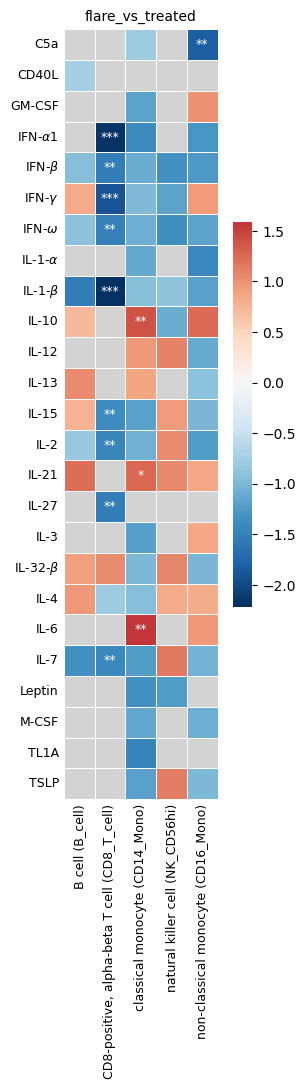

In [17]:
hc.plot_significant_results(
    nes_plot_df=nes_plot_df,
    annot_plot_df=annot_plot_df,
    robust_results=robust_results,
    selected_celltypes=None,
    selected_cytokines=None,
    fontsize=9,
    save_fig=False,
    fig_path="",
    fig_width=10.0,
    fig_height=10.0,
)

Earlier, we ran enrichment analyses over several contrast conditions, which returned the dataframe `multi_contrast_enrichment_results`. To visualize enrichment results across contrasts, you can plot multiple heatmaps side by side. You can do this manually by looping through the contrast conditions. Pass an `ax` argument to `plot_significant_results` to draw into a specific subplot. Otherwise, they will be plotted separately. If no robust results exist for a contrast, the subplot is left empty.

Star annotation mapping: * = 0.1, ** = 0.05, *** = 0.01
The contrast present in your enrichment results are: ['flare_vs_treated', 'flare_vs_managed', 'flare_vs_na'], but computing robustness only for: 'flare_vs_treated'


flare_vs_treated


100%|██████████| 5/5 [00:00<00:00, 25.62it/s]
Star annotation mapping: * = 0.1, ** = 0.05, *** = 0.01
The contrast present in your enrichment results are: ['flare_vs_treated', 'flare_vs_managed', 'flare_vs_na'], but computing robustness only for: 'flare_vs_managed'


flare_vs_managed


100%|██████████| 5/5 [00:00<00:00, 25.73it/s]
Star annotation mapping: * = 0.1, ** = 0.05, *** = 0.01
The contrast present in your enrichment results are: ['flare_vs_treated', 'flare_vs_managed', 'flare_vs_na'], but computing robustness only for: 'flare_vs_na'


flare_vs_na


100%|██████████| 5/5 [00:00<00:00, 25.42it/s]


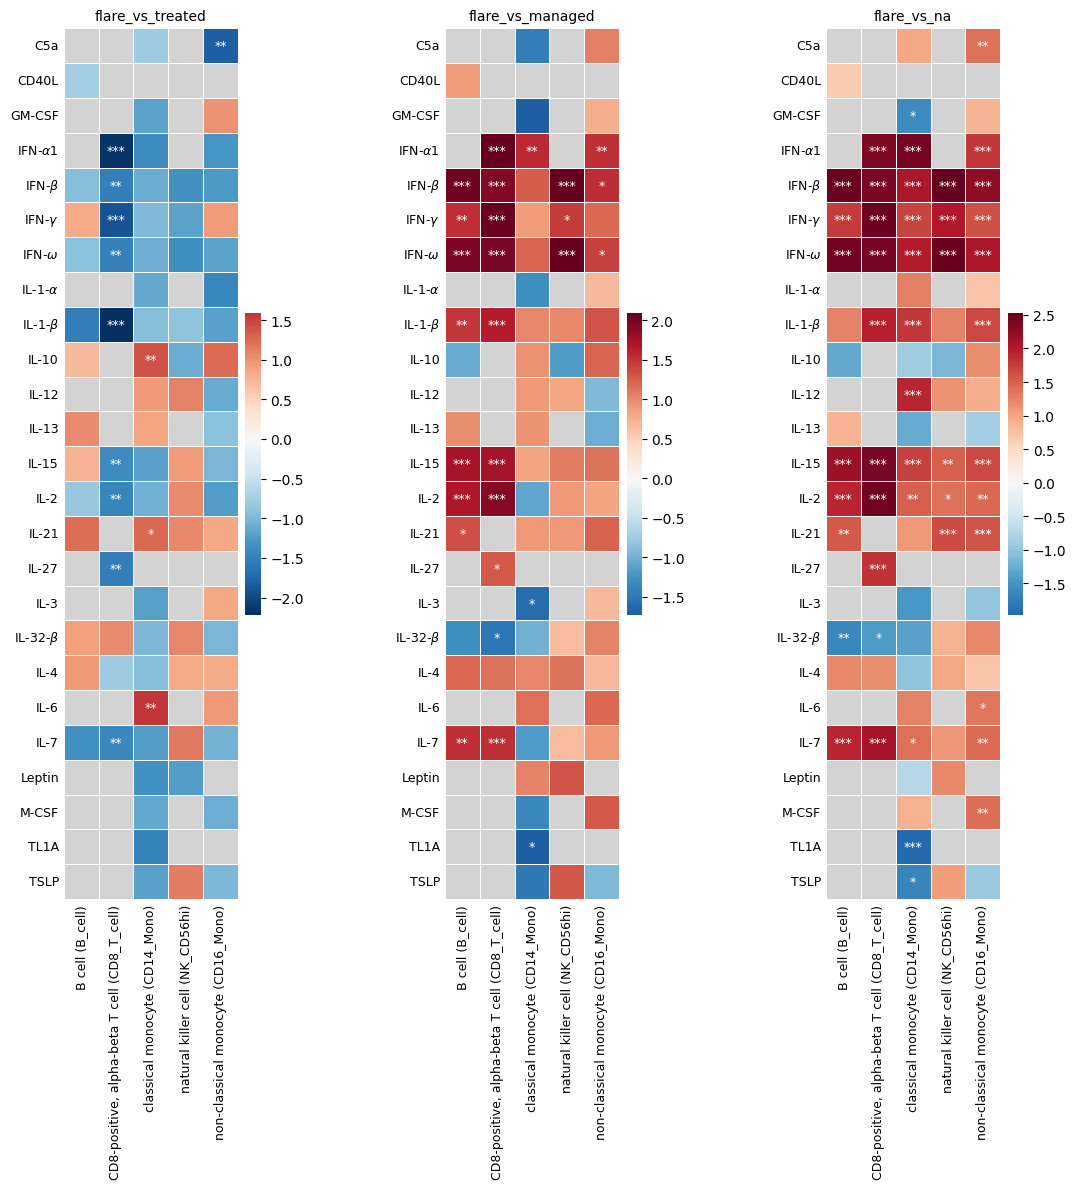

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 12))

for idx, contrast in enumerate(multi_contrast_enrichment_results.contrast.unique()):
    print(contrast)
    nes_plot_df, annot_plot_df, robust_results = hc.get_robust_significant_results(
        results=multi_contrast_enrichment_results,
        contrast_combo=contrast,
        alphas=[0.1, 0.05, 0.01],
        threshold_valid=0.1,
        threshold_below_alpha=0.9,
        display_robust_results=False,
    )

    if robust_results is not None and not robust_results.empty:
        hc.plot_significant_results(
            nes_plot_df,
            annot_plot_df,
            robust_results,
            ax=axes[idx],
            fontsize=9,
        )
    else:
        axes[idx].set_axis_off()
        axes[idx].set_title(f"{contrast}\nNo robust significant results")

plt.tight_layout()
plt.subplots_adjust(wspace=0.01)
plt.show()

### Cell-cell communication: compute senders and receivers

`get_all_senders_and_receivers()` identifies which cell types produce a cytokine (senders) and which express its receptor (receivers). Pass in the list of cytokines you want to analyze via `cytokine_list`, typically the robust cytokines from the enrichment analysis, or a custom set. They must be present in the cytokine information file to define sender and receiver relationships. The function will then identify which genes are in your query data as well.

- **`sender_pvalue_threshold`** — maximum p-value (from a Wilcoxon rank-sum test across cell types) for a cell type to be considered a sender. Only cell types where the cytokine gene is significantly more expressed compared to other cell types are included.
- **`receiver_mean_X_threshold`** — minimum mean receptor gene expression for a cell type to be considered a receiver. Set to 0 to include all cell types with any detectable receptor expression.

In [19]:
cytokine_info = hc.load_cytokine_info()
cytokine_info.head()

Loading from: /ictstr01/home/icb/jenni.liu/all_projects/cytokine_dict_project/huCIRA/docs/notebooks/cytokine_info.xlsx


,Unnamed: 0,name,gene,used cytokines,DEG_plot_family,single_family,family_level_1,family_level_2,receptor gene,alternative names,comments,parse_cytokine,single_gene,go_annotations,go_labels,functional_classification
0,0,IL-1-alpha,IL1A,IL-1α,IL-1,IL-1,interleukin,IL-1,"IL1R1, IL1RAP",Interleukin 1 alpha,NaN,True,IL1A,"['GO:0005125', 'GO:0046688', 'GO:0034605', 'GO...","cytokine activity, extracellular space, positi...",Pro-inflammatory
1,1,IL-1-beta,IL1B,IL-1β,IL-1,IL-1,interleukin,IL-1,"IL1R1, IL1RAP",Interleukin 1 beta,NaN,True,IL1B,"['GO:0005125', 'GO:0070372', 'GO:0001934', 'GO...","cytokine activity, positive regulation of prot...",Pro-inflammatory
2,2,IL-1Ra,IL1RN,IL-1Ra,IL-1,IL-1,interleukin,IL-1,IL1R1,Interleukin 1 receptor antagonist,NaN,True,IL1RN,"['GO:0006953', 'GO:0005813', 'GO:0005149', 'GO...","extracellular space, protein binding, cytosol,...",Anti-inflammatory
3,3,IL-18,IL18,IL-18,IL-1,IL-1,interleukin,IL-1,"IL18R1, IL18RAP",Interleukin 18,NaN,True,IL18,"['GO:0005125', 'GO:0005615', 'GO:0032819', 'GO...","cytokine activity, extracellular space, positi...","Pro-inflammatory, Th1-associated"
4,4,IL-33,IL33,IL-33,IL-1,IL-1,interleukin,IL-1,"IL1RL1, IL1RAP",Interleukin 33,NaN,True,IL33,"['GO:0005125', 'GO:0005737', 'GO:0005615', 'GO...","cytokine activity, cytoplasm, extracellular sp...",Pro-inflammatory


In [20]:
df_senders, df_receivers = hc.get_all_senders_and_receivers(
    adata=adata,
    cytokine_info=cytokine_info,
    cytokine_list=robust_results.cytokine.unique(),
    celltype_colname=your_celltype_colname,
    sender_pvalue_threshold=0.1,
    receiver_mean_X_threshold=0,
)

None of the cytokine producing genes (['IFNW1']) were found in dataset for cytokine IFN-omega.
No receptor gene found in cytokine_info for cytokine: IL-32-beta
None of the cytokine producing genes (['IFNA1']) were found in dataset for cytokine IFN-alpha1.
The following cytokine producing genes were not found in the dataset and are excluded: ['IL12B']


In [21]:
df_senders.head()

,min_logfoldchanges,min_pvals,min_pvals_adj,gene,mean_X,frac_X,mean_X>0,cytokine,celltype
"CD8-positive, alpha-beta T cell",2.76905,0.0,0.0,IFNG,0.054769,0.058260,0.054769,IFN-gamma,"CD8-positive, alpha-beta T cell"
lymphocyte,2.511762,0.0,0.0,IFNG,0.092878,0.185006,0.092878,IFN-gamma,lymphocyte
natural killer cell,1.741828,0.0,0.0,IFNG,0.049104,0.054678,0.049104,IFN-gamma,natural killer cell
classical monocyte,1.848429,0.0,0.0,IL15,0.029858,0.049086,0.029858,IL-15,classical monocyte
non-classical monocyte,1.758463,0.0,0.0,IL15,0.041609,0.090384,0.041609,IL-15,non-classical monocyte


In [22]:
df_receivers.head()

,mean_X,frac_X,cytokine,celltype
B cell,0.030110,0.045329,IFN-beta,B cell
lymphocyte,0.054595,0.139057,IFN-beta,lymphocyte
natural killer cell,0.034506,0.044113,IFN-beta,natural killer cell
"CD4-positive, alpha-beta T cell",0.042741,0.065390,IFN-beta,"CD4-positive, alpha-beta T cell"
"CD8-positive, alpha-beta T cell",0.037064,0.055736,IFN-beta,"CD8-positive, alpha-beta T cell"


### Cell-cell communication circos plot

`plot_communication()` visualizes which cell types send and receive cytokine signals using a circos plot. It requires sender and receiver DataFrames computed by `get_all_senders_and_receivers()`, which identifies for each cytokine which cell types express the cytokine gene (senders) and which express its receptor (receivers). For an overview, refer to `quick_start_cell-cell_communication.ipynb`.

#### Filtering communication links

The circos plot can get crowded when many cell types and cytokines are involved. Several parameters let you filter which communication links are shown:

- **`frac_expressing_cells_sender` / `frac_expressing_cells_receiver`** — minimum fraction of cells in a cell type that must express the cytokine gene (sender) or the receptor gene (receiver). This removes links driven by only a handful of cells, which are less likely to reflect real communication.

- **`mean_cytokine_gene_expression_sender` / `mean_cytokine_gene_expression_receiver`** — minimum mean expression level of the cytokine or receptor gene in a cell type. This filters out cell types where the gene is technically detected but at very low levels. These thresholds should be set in the same scale as your expression data (e.g. log-normalized).

- **`df_enrichment`** — if provided, only cytokines that appear in this DataFrame are plotted. Typically, you pass in the robust enrichment results so that the circos plot only shows cytokines with significant enrichment in at least one cell type.

- **`all_celltypes`** — if not provided, only cell types present in the sender and receiver DataFrames are plotted. In this tutorial, all cell type groups of the query data are passed so that all are visualized.

#### Appearance

Colors for cytokines and cell types are assigned automatically, but you can provide your own mappings via `cytokine2color` and `celltype2color`. Use `figsize` to adjust the plot size, `lw` for the line width of signaling arrows, and `fontsize` for the labels. `loc` and `bbox_to_anchor` control the position of the legend. The figure is only saved if `save_path` is specified.

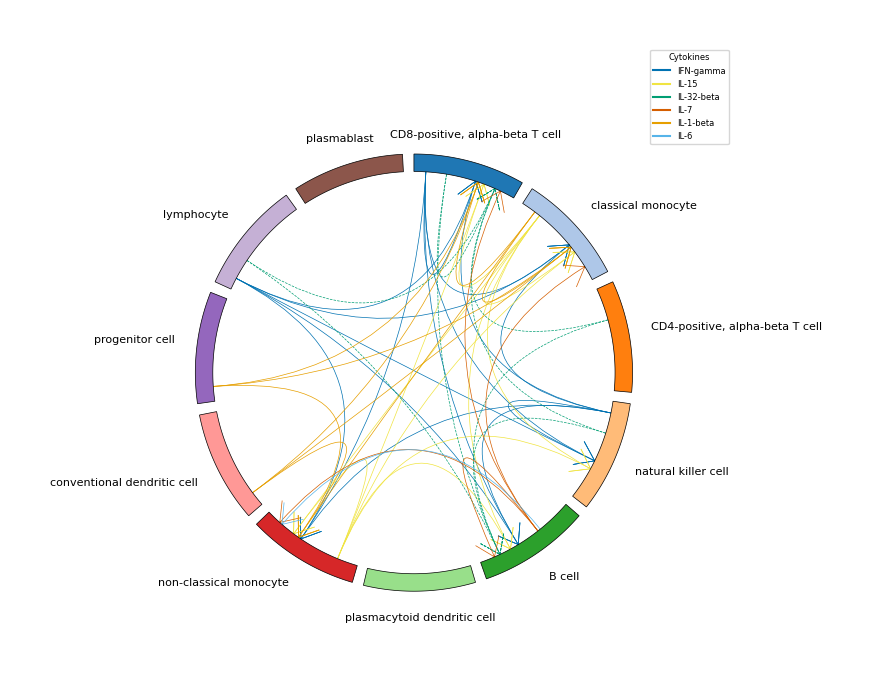

In [23]:
# Plots cell-cell communication

expression_threshold = 0.1 / 10_000  # = 100 TPM
expression_threshold = np.log2((expression_threshold) + 1)

legend_handles, legend_labels = hc.plot_communication(
    df_src=df_senders,
    df_tgt=df_receivers,
    df_enrichment=robust_results,
    all_celltypes=np.array(adata.obs[your_celltype_colname].unique()),
    # Filtering statistics
    frac_expressing_cells_sender=0,
    frac_expressing_cells_receiver=0,
    mean_cytokine_gene_expression_sender=expression_threshold,
    mean_cytokine_gene_expression_receiver=expression_threshold,
    # map your custom cytokine and cell type colors as dictionaries
    cytokine2color=None,
    celltype2color=None,
    # Plotting aeshetics
    show_legend=True,
    figsize=(8, 9),
    lw=0.5,
    fontsize=8,
    bbox_to_anchor=(1.1, 1.1),
    loc="center",
    save_path=None,
)

In [24]:
end = time.time()
print(f"Time: {int((end - start) / 60)} min {int((end - start) % 60)} sec")

Time: 6 min 11 sec


In [ ]:
## --END-- ##